# **Proyecto 2**

## **Analítica Computacional para la Toma de Decisiones**

### **Integrantes**:

**Juan Camilo Gómez - 202220238 - j.gomezu@uniandes.edu.co**

**Jerónimo Rueda - 202223775 - j.ruedar2@uniandes.edu.co**


### **Librerias**

In [1]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns  
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, r2_score)


c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Datos**

In [2]:
df = pd.read_csv("Saber 11 Datos Valle.csv")


mapaarreglo = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

df["estrato_num"] = df["fami_estratovivienda"].map(mapaarreglo)


#df[df["fami_estratovivienda"]=="Sin Estrato"][["estrato_num", "fami_estratovivienda"]].head()

df[df["punt_lectura_critica"].isna()]["periodo"].value_counts()

df=df[df["punt_global"].notna()]
df=df.drop_duplicates()


df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    format="%d/%m/%Y",
    errors="coerce"
)
df["estu_fechanacimiento"].isna().sum()

#df["estu_fechanacimiento"].describe()

#df.loc[641382, ["estu_fechanacimiento","periodo"]]

df["año"]=df["periodo"].astype(str).str[:4]



ti_menoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 17).astype(str),format="%d/%m/%Y")

cc_mayoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 18).astype(str),format="%d/%m/%Y")

reemplazofechanac = df["estu_fechanacimiento"].isna() | (df["estu_fechanacimiento"].dt.year == 1900)

df.loc[reemplazofechanac, "estu_fechanacimiento"] = np.where(
    df.loc[reemplazofechanac, "estu_tipodocumento"].eq("TI"),
    ti_menoresedad.loc[reemplazofechanac],
    cc_mayoresedad.loc[reemplazofechanac]
)
#df.loc[df["estu_fechanacimiento"].isna(), "estu_fechanacimiento"] = np.where(df["estu_tipodocumento"] == "TI",ti_menoresedad,cc_mayoresedad)
#df[df["estu_fechanacimiento"].isna()][["estu_fechanacimiento","periodo","estu_tipodocumento"]][["periodo","estu_tipodocumento"]].value_counts() 

df=df[df["año"].astype(int)>2014]

#print(df["estu_fechanacimiento"].sort_values().head(50))
#print(df["estu_fechanacimiento"].sort_values().tail(10))

reemplazos = {
    "CALIMA": "CALIMA EL DARIEN",
    "CALIMA (DARIEN)": "CALIMA EL DARIEN",
    "BUGA": "GUADALAJARA DE BUGA",
    "JAMUNDÍ": "JAMUNDI",
    "ALCALÁ": "ALCALA",
    "ANDALUCÍA": "ANDALUCIA",
    "BOLÍVAR": "BOLIVAR",
    "EL ÁGUILA": "EL AGUILA",
    "GUACARÍ": "GUACARI",
    "RIOFRÍO": "RIOFRIO",
    "LA UNIÓN": "LA UNION",
    "TULUÁ": "TULUA"
}

df["cole_mcpio_ubicacion"] = df["cole_mcpio_ubicacion"].replace(reemplazos)
print(df["cole_mcpio_ubicacion"].unique().tolist())

['CALI', 'GUADALAJARA DE BUGA', 'JAMUNDI', 'RESTREPO', 'BUENAVENTURA', 'CALIMA EL DARIEN', 'YUMBO', 'CANDELARIA', 'TULUA', 'PALMIRA', 'CARTAGO', 'BOLIVAR', 'DAGUA', 'EL CERRITO', 'ALCALA', 'ROLDANILLO', 'SAN PEDRO', 'LA CUMBRE', 'CAICEDONIA', 'FLORIDA', 'ZARZAL', 'OBANDO', 'TRUJILLO', 'ANDALUCIA', 'VIJES', 'RIOFRIO', 'VERSALLES', 'GINEBRA', 'PRADERA', 'LA VICTORIA', 'BUGALAGRANDE', 'SEVILLA', 'GUACARI', 'ANSERMANUEVO', 'LA UNION', 'EL DOVIO', 'TORO', 'ARGELIA', 'YOTOCO', 'ULLOA', 'EL AGUILA', 'EL CAIRO']


### **Faltantes**

In [3]:
#df.isna().sum()

df[["cole_cod_mcpio_ubicacion","estrato_num"]].groupby("cole_cod_mcpio_ubicacion").value_counts()
prom_estrato=(df.groupby("cole_cod_mcpio_ubicacion")["estrato_num"].transform("mean").round())

df["estrato_num"] = df["estrato_num"].fillna(prom_estrato).astype("Int64")
df["fami_estratovivienda"]=df["fami_estratovivienda"].fillna("Estrato"+prom_estrato.astype("string")).astype("string")

#print(prom_estrato)

#df[df["cole_bilingue"].isna()].describe()
#df[["cole_bilingue","estrato_num"]].groupby("cole_bilingue").value_counts()
df["cole_bilingue"] = df["cole_bilingue"].fillna("Desconocido")
df["cole_caracter"] = df["cole_caracter"].fillna("Desconocido")
df["cole_cod_dane_establecimiento"] = df["cole_cod_dane_establecimiento"].fillna("Desconocido (Instituto Tecnológico Gran Colombia)")
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].fillna("RURAL")
df["cole_cod_dane_establecimiento"] = df["cole_area_ubicacion"].fillna("RURAL")
df["estu_cod_depto_presentacion"] = df["estu_cod_depto_presentacion"].fillna(df["estu_cod_reside_depto"])
df["estu_depto_presentacion"] = df["estu_depto_presentacion"].fillna(df["estu_depto_reside"])

df["estu_cod_mcpio_presentacion"] = df["estu_cod_mcpio_presentacion"].fillna(df["estu_cod_reside_mcpio"])
df["estu_cod_reside_depto"] = df["estu_cod_reside_depto"].fillna(df["cole_depto_ubicacion"])
df["estu_cod_reside_mcpio"] = df["estu_cod_reside_mcpio"].fillna(df["cole_mcpio_ubicacion"])
df["estu_depto_reside"] = df["estu_depto_reside"].fillna(df["estu_depto_presentacion"])
df["estu_genero"] = df["estu_genero"].fillna("Desconocido")
df["estu_mcpio_presentacion"] = df["estu_mcpio_presentacion"].fillna(df["cole_mcpio_ubicacion"])
df["estu_mcpio_reside"] = df["estu_mcpio_reside"].fillna(df["cole_mcpio_ubicacion"])

df["fami_cuartoshogar"] = df["fami_cuartoshogar"].fillna("Desconocido")
df["fami_educacionmadre"] = df["fami_educacionmadre"].fillna("Desconocido")
df["fami_educacionpadre"] = df["fami_educacionpadre"].fillna("Desconocido")
df["fami_personashogar"] = df["fami_personashogar"].fillna("Desconocido")
df["fami_tieneautomovil"] = df["fami_tieneautomovil"].fillna("No")
df["fami_tienecomputador"] = df["fami_tienecomputador"].fillna("No")
df["fami_tieneinternet"] = df["fami_tieneinternet"].fillna(df["fami_tienecomputador"])
df["fami_tienelavadora"] = df["fami_tienelavadora"].fillna("No")




#df[df["cole_area_ubicacion"].isna()].head()
#df[["cole_cod_dane_establecimiento","cole_cod_mcpio_ubicacion"]]["cole_cod_dane_establecimiento"].isna().groupby(df["cole_cod_mcpio_ubicacion"]).value_counts()
#df[df["cole_cod_dane_establecimiento"].isna()]["cole_nombre_establecimiento"].value_counts()
df[df["desemp_ingles"].isna()]["estrato_num"].value_counts()
#df["fami_tienecomputador"].value_counts()

corr_mat = df[["punt_ingles", "punt_matematicas", "punt_lectura_critica"]].corr()
c_mat = abs(corr_mat["punt_ingles"]["punt_matematicas"])
c_lec = abs(corr_mat["punt_ingles"]["punt_lectura_critica"])
suma_c = c_mat + c_lec
reemplazo = ((c_mat / suma_c) * df["punt_matematicas"] + (c_lec / suma_c) * df["punt_lectura_critica"])
df["punt_ingles"] = df["punt_ingles"].fillna(round(reemplazo, 0))


df[df["desemp_ingles"].isna()]["punt_ingles"].describe()



"""
if df["punt_ingles"]<27:

    df["desemp_ingles"]=df["desemp_ingles"].fillna("A1")

elif df["punt_ingles"]<=40:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("A2")
elif df["punt_ingles"]<55:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B1")
else:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B+")
"""

condiciones = [df["punt_ingles"] < 27,df["punt_ingles"] <= 40,df["punt_ingles"] < 55]
valores = ["A1", "A2", "B1"]
#df["desemp_ingles"].value_counts()

nivel_calc = np.select(condiciones, valores, default="B+")

df["desemp_ingles"] = df["desemp_ingles"].fillna(pd.Series(nivel_calc, index=df.index))


categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)
df["año"]=df["periodo"].astype(str).str[:4]

df=df[df["año"].astype(int)>2014]
df.isna().sum()


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_14500\3873154715.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_14500\3873154715.py:82: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downca

periodo                          0
estu_tipodocumento               0
estu_consecutivo                 0
cole_area_ubicacion              0
cole_bilingue                    0
cole_calendario                  0
cole_caracter                    0
cole_cod_dane_establecimiento    0
cole_cod_dane_sede               0
cole_cod_depto_ubicacion         0
cole_cod_mcpio_ubicacion         0
cole_codigo_icfes                0
cole_depto_ubicacion             0
cole_genero                      0
cole_jornada                     0
cole_mcpio_ubicacion             0
cole_naturaleza                  0
cole_nombre_establecimiento      0
cole_nombre_sede                 0
cole_sede_principal              0
estu_cod_depto_presentacion      0
estu_cod_mcpio_presentacion      0
estu_cod_reside_depto            0
estu_cod_reside_mcpio            0
estu_depto_presentacion          0
estu_depto_reside                0
estu_estadoinvestigacion         0
estu_estudiante                  0
estu_fechanacimiento

### **Puntajes a Variables Categóricas**

In [4]:
puntajes=df.copy()


puntajes["Puntaje area ubicacion"] = puntajes["cole_area_ubicacion"].map({"URBANO": 1, "RURAL": 0})
puntajes["Puntaje bilingue"] = puntajes["cole_bilingue"].map({"S": 1, "N": 0})
#puntajes["Puntaje calendario"] = puntajes["cole_calendario"].map({"A": 1, "B": 2,"OTROS": 3})
#puntajes["Puntaje caracter"] = puntajes["cole_caracter"].map({"TÉCNICO/ACADÉMICO": 1, "ACADÉMICO": 2,"TÉCNICO": 3,"NO APLICA": 4})
puntajes["Puntaje Genero col"] = puntajes["cole_genero"].map({"MIXTO": 1, "FEMENINO": 2,"MASCULINO": 3})
puntajes["Puntaje Jornada"] = puntajes["cole_jornada"].map({"MAÑANA": 1, "TARDE": 2,"COMPLETA": 3,"NOCHE": 4,"UNICA": 5,"SABATINA":6})
puntajes["Puntaje Naturaleza"] = puntajes["cole_naturaleza"].map({"OFICIAL": 1, "NO OFICIAL": 0})
puntajes["Puntaje Sede Principal"] = puntajes["cole_sede_principal"].map({"S": 1, "N": 0})
puntajes["Puntaje Investigación"] = puntajes["estu_estadoinvestigacion"].map({"PUBLICAR": 3, "VALIDEZ OFICINA JURÍDICA": 2,"PRESENTE CON LECTURA TARDIA":1,"NO SE COMPROBO IDENTIDAD DEL EXAMINADO":0})
#puntajes["Puntaje Genero"] = puntajes["estu_genero"].map({"M": 0, "F": 1})
puntajes["Puntaje Libertad"] = puntajes["estu_privado_libertad"].map({"S": 0, "N": 1})
puntajes["Puntaje Cuartos Hogar"] = puntajes["fami_cuartoshogar"].map({"Uno": 1, "Dos": 2,"Tres": 3,"Cuatro": 4,"Cinco": 5,"Seis":6,"Seis o mas": 6.5,"Siete": 7,"Ocho": 8,"Nueve": 9,"Diez o más": 10})

puntajes["Puntaje Educación Madre"] = puntajes["fami_educacionmadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Educación Padre"] = puntajes["fami_educacionpadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Personas Hogar"] = puntajes["fami_personashogar"].map({"Una": 1, "1 a 2":1.5,"Dos": 2,"Tres": 3,"3 a 4":3.5,"Cuatro": 4,"Cinco": 5,
                                                                         "5 a 6":5.5,"Seis": 6,"Siete": 7,"7 a 8":7.5,"Ocho": 8,"Nueve": 9,"9 o más":9.5,
                                                                         "Diez": 10,"Doce o más": 10})
puntajes["Puntaje Automóvil"] = puntajes["fami_tieneautomovil"].map({"Si": 1, "No": 0})
puntajes["Puntaje Computador"] = puntajes["fami_tienecomputador"].map({"Si": 1, "No": 0})

puntajes["Puntaje Lavadora"] = puntajes["fami_tienelavadora"].map({"Si": 1, "No": 0})
puntajes["Puntaje Desempeño ingles"] = puntajes["desemp_ingles"].map({"A-":0,"A1": 1, "A2": 2,"B1": 3,"B+": 4})


puntajes["desemp_ingles"].value_counts()
def normalizar(s):
    return (s.str.normalize("NFKD")
                .str.encode("ascii","ignore")
                .str.decode("utf-8").str.upper()
                .str.strip())
puntajes["cole_mcpio_ubicacion"] = (df["cole_mcpio_ubicacion"].pipe(normalizar))
puntajes["cole_mcpio_ubicacion"] = puntajes["cole_mcpio_ubicacion"].replace(["CALIMA (DARIEN)", "CALIMA"], "CALIMA EL DARIEN")
mapazonas= {
    # Zona Pacífico 
    "BUENAVENTURA": "Pacífico",
    # Zona Centro
    "CALIMA EL DARIEN": "Centro",
    "YOTOCO": "Centro",
    "SAN PEDRO": "Centro",
    "GUADALAJARA DE BUGA": "Centro",   
    "BUGA": "Centro",                  
    "GUACARI": "Centro",
    "GINEBRA": "Centro",
    "EL CERRITO": "Centro",
    # Zona Sur 
    "DAGUA": "Sur",
    "LA CUMBRE": "Sur",
    "VIJES": "Sur",
    "YUMBO": "Sur",
    "CALI": "Sur",
    "PALMIRA": "Sur",
    "CANDELARIA": "Sur",
    "PRADERA": "Sur",
    "FLORIDA": "Sur",
    "JAMUNDI": "Sur",
    "RESTREPO": "Sur",
    # Zona Norte
    "ALCALA": "Norte",
    "ULLOA": "Norte",
    "CARTAGO": "Norte",
    "ANSERMANUEVO": "Norte",
    "EL AGUILA": "Norte",
    "EL CAIRO": "Norte",
    "VERSALLES": "Norte",
    "ARGELIA": "Norte",
    "TORO": "Norte",
    "OBANDO": "Norte",
    "LA VICTORIA": "Norte",
    "LA UNION": "Norte",
    "ROLDANILLO": "Norte",
    "ZARZAL": "Norte",
    "BOLIVAR": "Norte",
    "TRUJILLO": "Norte",
    "RIOFRIO": "Norte",
    "EL DOVIO": "Norte",
    "ANDALUCIA": "Norte",
    "BUGALAGRANDE": "Norte",
    "TULUA": "Norte",
    "SEVILLA": "Norte",
    "CAICEDONIA": "Norte"}

puntajes["Zona"] = puntajes["cole_mcpio_ubicacion"].map(mapazonas)

puntajes["Puntaje bilingue"].fillna(puntajes["Puntaje bilingue"].mode()[0],inplace=True)
ordenlogico = ["Puntaje Educación Madre","Puntaje Educación Padre","Puntaje Personas Hogar","Puntaje Cuartos Hogar"]
for col in ordenlogico:
    puntajes[col] = puntajes[col].fillna(puntajes.groupby("fami_estratovivienda")[col].transform("mean"))
puntajes["año"] = puntajes["año"].astype(int)
puntajes["Puntaje educacion padres"] = puntajes["Puntaje Educación Padre"]+puntajes["Puntaje Educación Madre"]
puntajes["Puntaje recursos hogar"] = puntajes["Puntaje Automóvil"]+puntajes["Puntaje Computador"]+puntajes["Puntaje Lavadora"]
#puntajes["Puntaje Genero"] = puntajes["estu_genero"].map({"M": 0, "F": 1})
puntajes_solonum = puntajes.iloc[:, 45:].copy()
puntajes2020s=puntajes[puntajes["año"].astype(int)>=2020]


# Mapear categóricas adicionales que estaban quedando fuera
puntajes2020s["Puntaje Caracter"] = puntajes2020s["cole_caracter"].map(
    {"TÉCNICO/ACADÉMICO":1,"ACADÉMICO":2,"TÉCNICO":3,"NO APLICA":4,"Desconocido":0}).fillna(0)
puntajes2020s["Puntaje Calendario"] = puntajes2020s["cole_calendario"].map(
    {"A":1,"B":2,"OTROS":3}).fillna(0)

# Interacciones
puntajes2020s["int_estrato_edu"]   = puntajes2020s["estrato_num"] * puntajes2020s["Puntaje educacion padres"]
puntajes2020s["int_urbano_estrato"] = puntajes2020s["Puntaje area ubicacion"] * puntajes2020s["estrato_num"]
puntajes2020s["int_natur_estrato"]  = puntajes2020s["Puntaje Naturaleza"] * puntajes2020s["estrato_num"]

print("Nuevas columnas listas:", ["Puntaje Caracter","Puntaje Calendario",
    "int_estrato_edu","int_urbano_estrato","int_natur_estrato"])

C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_14500\3579908730.py:98: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  puntajes["Puntaje bilingue"].fillna(puntajes["Puntaje bilingue"].mode()[0],inplace=True)


Nuevas columnas listas: ['Puntaje Caracter', 'Puntaje Calendario', 'int_estrato_edu', 'int_urbano_estrato', 'int_natur_estrato']


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_14500\3579908730.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puntajes2020s["Puntaje Caracter"] = puntajes2020s["cole_caracter"].map(
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_14500\3579908730.py:113: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puntajes2020s["Puntaje Calendario"] = puntajes2020s["cole_calendario"].map(
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_14500\3579908730.py:117: SettingWithCopyWarning: 
A va

In [5]:
columnas=puntajes2020s.columns
for i in columnas:
    print(f"Columna:{i} , Ejemplo: {puntajes2020s[i][2]}")

Columna:periodo , Ejemplo: 20224
Columna:estu_tipodocumento , Ejemplo: TI
Columna:estu_consecutivo , Ejemplo: SB11202240151458
Columna:cole_area_ubicacion , Ejemplo: URBANO
Columna:cole_bilingue , Ejemplo: N
Columna:cole_calendario , Ejemplo: A
Columna:cole_caracter , Ejemplo: TÉCNICO/ACADÉMICO
Columna:cole_cod_dane_establecimiento , Ejemplo: URBANO
Columna:cole_cod_dane_sede , Ejemplo: 176364001313.0
Columna:cole_cod_depto_ubicacion , Ejemplo: 76
Columna:cole_cod_mcpio_ubicacion , Ejemplo: 76364
Columna:cole_codigo_icfes , Ejemplo: 671156.0
Columna:cole_depto_ubicacion , Ejemplo: VALLE
Columna:cole_genero , Ejemplo: MIXTO
Columna:cole_jornada , Ejemplo: UNICA
Columna:cole_mcpio_ubicacion , Ejemplo: JAMUNDI
Columna:cole_naturaleza , Ejemplo: OFICIAL
Columna:cole_nombre_establecimiento , Ejemplo: INSTITUCION EDUCATIVA TÉCNICA INDUSTRIAL ESPAÑA
Columna:cole_nombre_sede , Ejemplo: TÉCNICA INDUSTRIAL ESPAÑA-SEDE PRINCIPAL
Columna:cole_sede_principal , Ejemplo: S
Columna:estu_cod_depto_pres

In [6]:
semilla = 42

tamaño_test = 0.2
porcentaje=tamaño_test/(1-tamaño_test)

In [ ]:
Conj_num = ["estrato_num","Puntaje area ubicacion","Puntaje bilingue","Puntaje Naturaleza",
            "Puntaje Jornada","Puntaje Genero col","Puntaje Sede Principal",
            "Puntaje Cuartos Hogar","Puntaje Educación Madre","Puntaje Educación Padre",
            "Puntaje Personas Hogar","Puntaje Automóvil","Puntaje Computador","Puntaje Lavadora",
            "Puntaje educacion padres","Puntaje recursos hogar",
            "Puntaje Caracter","Puntaje Calendario",
            "int_estrato_edu","int_urbano_estrato","int_natur_estrato","año"]

Conj_cat = ["Zona","estu_genero","fami_tieneinternet"]

# Mantenemos cole_mcpio_ubicacion como CLAVE (no como dummy) para hacer target encoding
base = puntajes2020s[Conj_num + Conj_cat + ["cole_mcpio_ubicacion","punt_global"]].copy()
base["año"] = base["año"].astype(int)
y = base["punt_global"].astype(float).values
y_separado = pd.qcut(y, q=10, labels=False, duplicates='drop')

idx_trainval, idx_test = train_test_split(np.arange(len(base)), test_size=0.15,
                                          random_state=semilla, stratify=y_separado)
idx_train, idx_val = train_test_split(idx_trainval, test_size=porcentaje,
                                      random_state=semilla, stratify=y_separado[idx_trainval])

# Target encoding del municipio — SOLO con train, con smoothing
mu_global = y[idx_train].mean()
k_smooth = 30  # municipios con <30 estudiantes en train se promedian con la media global
stats = pd.DataFrame({"m":pd.Series(y[idx_train]).groupby(base.iloc[idx_train]["cole_mcpio_ubicacion"].values).mean(),
                      "n":pd.Series(y[idx_train]).groupby(base.iloc[idx_train]["cole_mcpio_ubicacion"].values).size()})
stats["mcpio_te"] = (stats["n"]*stats["m"] + k_smooth*mu_global) / (stats["n"]+k_smooth)
te_map = stats["mcpio_te"].to_dict()
base["mcpio_te"] = base["cole_mcpio_ubicacion"].map(te_map).fillna(mu_global)

# X final
X = pd.get_dummies(base[Conj_num + Conj_cat + ["mcpio_te"]], columns=Conj_cat, drop_first=True)
X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
print(f"Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape} | n_features={X.shape[1]}")

X_escalar = StandardScaler()
X_train_s = X_escalar.fit_transform(X_train); X_val_s = X_escalar.transform(X_val); X_test_s = X_escalar.transform(X_test)
Y_escalar = StandardScaler()
y_train_s = Y_escalar.fit_transform(y_train.reshape(-1,1)).flatten()
y_val_s = Y_escalar.transform(y_val.reshape(-1,1)).flatten()
y_test_s = Y_escalar.transform(y_test.reshape(-1,1)).flatten()

Train (38343, 28) | Val (12782, 28) | Test (9023, 28) | n_features=28


In [8]:
mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.set_experiment("Puntaje Prueba Saber")
n_feats = X_train.shape[1]

for n_est in [100, 300, 500]:
    for max_d in [8, 14, 20]:
        for max_f in ["sqrt", min(8, n_feats)]:
            with mlflow.start_run(experiment_id=experimento.experiment_id, run_name=f"RF_grid_{n_est}_{max_d}_{max_f}"):
                rf = RandomForestRegressor(n_estimators=n_est, max_depth=max_d,
                                           max_features=max_f, n_jobs=-1, random_state=semilla)
                # Entrenamiento y predicción AMBOS sin escalar (consistencia)
                rf.fit(X_train, y_train)
                pred = rf.predict(X_test)
                mlflow.log_params({"n_estimators":n_est,"max_depth":max_d,"max_features":str(max_f)})
                mlflow.log_metric("MSE", mean_squared_error(y_test, pred))
                mlflow.log_metric("RMSE", np.sqrt(mean_squared_error(y_test, pred)))
                mlflow.log_metric("R2", r2_score(y_test, pred))

c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [9]:
mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.set_experiment("Puntaje Prueba Saber")

def evaluar(y_true, y_pred, label=''):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    # Error porcentual medio absoluto sobre el rango (puntajes 0-500)
    mape_rango = float(np.mean(np.abs(y_true - y_pred)) / 500 * 100)
    out = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAE_pct_rango': mape_rango}
    if label:
        print(f'  [{label}]  RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.3f} | MAE%rango={mape_rango:.2f}%')
    return out

def plot_diagnostico(y_true, y_pred, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(y_true, y_pred, alpha=0.25, s=8)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', lw=1)
    axes[0].set_xlabel('Real'); axes[0].set_ylabel('Predicho')
    axes[0].set_title(f'{titulo} — Real vs Predicho')
    res = y_true - y_pred
    axes[1].hist(res, bins=40, edgecolor='black', alpha=0.75)
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title(f'Residuos (media={res.mean():.2f}, std={res.std():.2f})')
    plt.tight_layout(); plt.show()

=== Baseline: Random Forest ===
  [VAL ]  RMSE=44.10 | MAE=35.71 | R²=0.336 | MAE%rango=7.14%
  [TEST]  RMSE=44.41 | MAE=36.04 | R²=0.335 | MAE%rango=7.21%


2026/05/21 16:27:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


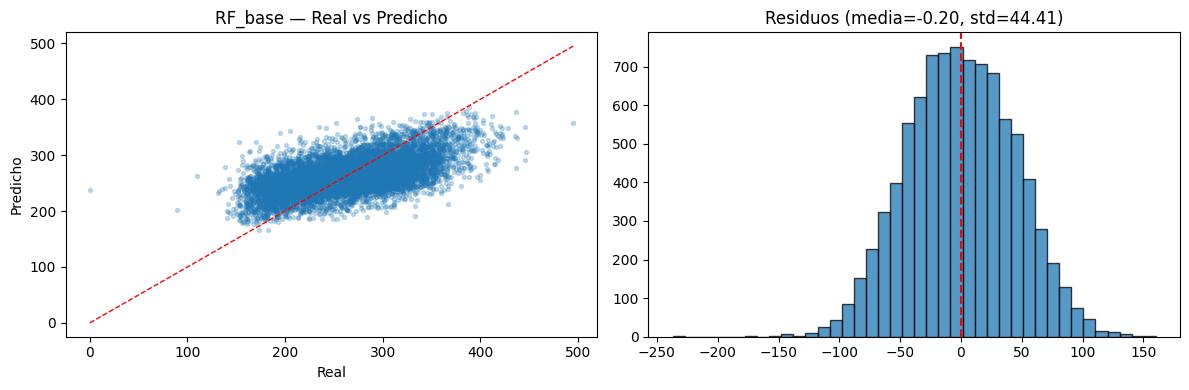

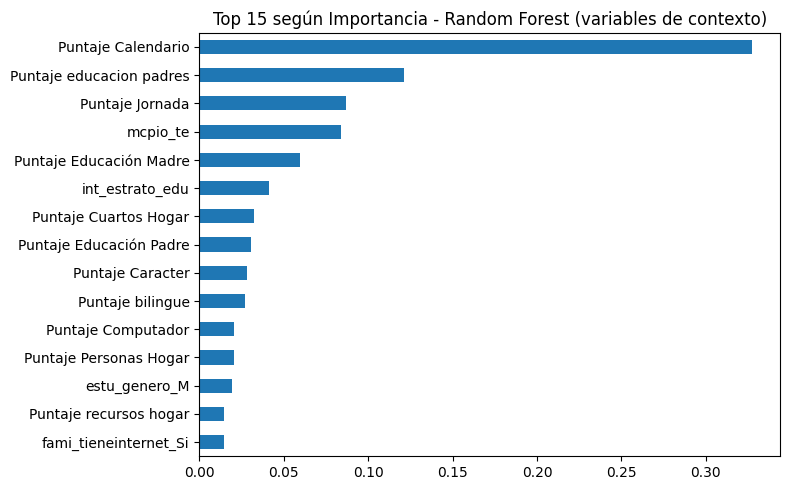

In [10]:
print('=== Baseline: Random Forest ===')
with mlflow.start_run(run_name='RF_baseline') as run:
    rf_params = dict(n_estimators=300, max_depth=14, min_samples_leaf=10,
                     n_jobs=-1, random_state=semilla)
    rf = RandomForestRegressor(**rf_params)
    rf.fit(X_train, y_train)
    pred_val  = rf.predict(X_val)
    pred_test = rf.predict(X_test)
    m_val  = evaluar(y_val,  pred_val,  'VAL ')
    m_test = evaluar(y_test, pred_test, 'TEST')

    mlflow.log_params({**rf_params, 'model_type':'RandomForest', 'n_features': X.shape[1]})
    for k,v in m_val.items():  mlflow.log_metric(f'val_{k}', v)
    for k,v in m_test.items(): mlflow.log_metric(f'test_{k}', v)
    mlflow.sklearn.log_model(rf, name='rf_model')
    rf_run_id = run.info.run_id

plot_diagnostico(y_test, pred_test, 'RF_base')

# Importancia de variables
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax)
ax.set_title('Top 15 según Importancia - Random Forest (variables de contexto)')
plt.tight_layout(); plt.show()

In [41]:
def hacer_redesneu(dimensiones, ocultas=(256,128,64), dropout=0.25, l2=5e-4, lr=8e-4, huber_delta=1.0):
    inputs = tf.keras.Input(shape=(dimensiones,))
    x = tf.keras.layers.BatchNormalization()(inputs)
    for h in ocultas:
        x = tf.keras.layers.Dense(h, kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1)(x)
    modelo = tf.keras.Model(inputs, out)
    modelo.compile(optimizer=tf.keras.optimizers.Adam(lr),
                   loss=tf.keras.losses.Huber(delta=huber_delta),
                   metrics=[tf.keras.metrics.RootMeanSquaredError(name='RMSE'),
                            tf.keras.metrics.MeanAbsoluteError(name='MAE')])
    return modelo

prueba = [
    {'Nombre':'NN_BN_pequeña', 'Capas Ocultas':(128,64),     'dropout':0.20,'l2':1e-4,'lr':1e-3,'epochs':150,'bs':256},
    {'Nombre':'NN_BN_mediana', 'Capas Ocultas':(256,128,64), 'dropout':0.25,'l2':5e-4,'lr':8e-4,'epochs':200,'bs':256},
    {'Nombre':'NN_BN_grande',  'Capas Ocultas':(512,256,128,64),'dropout':0.30,'l2':1e-3,'lr':5e-4,'epochs':250,'bs':512},
]
resultados = []
histories  = {}
models     = {}

for cfg in prueba:
    print(f'\n=== {cfg["Nombre"]} ===')
    tf.keras.backend.clear_session()
    tf.random.set_seed(semilla); np.random.seed(semilla)
    with mlflow.start_run(run_name=cfg['Nombre']) as run:
        model = hacer_redesneu(X_train_s.shape[1], cfg['Capas Ocultas'], cfg['dropout'], cfg['l2'], cfg['lr'])

        es = tf.keras.callbacks.EarlyStopping(
            patience=15, restore_best_weights=True, monitor='val_loss')
        rl = tf.keras.callbacks.ReduceLROnPlateau(
            patience=6, factor=0.5, monitor='val_loss', min_lr=1e-5)

        hist = model.fit(
            X_train_s, y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=cfg['epochs'], batch_size=cfg['bs'],
            callbacks=[es, rl], verbose=0
        )

        # Predicciones — desescalar antes de medir
        pred_val_s  = model.predict(X_val_s,  verbose=0).flatten()
        pred_test_s = model.predict(X_test_s, verbose=0).flatten()
        pred_val  = Y_escalar.inverse_transform(pred_val_s.reshape(-1,1)).flatten()
        pred_test = Y_escalar.inverse_transform(pred_test_s.reshape(-1,1)).flatten()

        m_val  = evaluar(y_val,  pred_val,  'VAL ')
        m_test = evaluar(y_test, pred_test, 'TEST')

        mlflow.log_params({
            'model_type':'NeuralNetwork',
            'hidden': str(cfg['Capas Ocultas']),
            'dropout': cfg['dropout'], 'l2': cfg['l2'], 'lr': cfg['lr'],
            'batch_size': cfg['bs'], 'epochs_max': cfg['epochs'],
            'epochs_trained': len(hist.history['loss']),
            'n_features': X.shape[1], 'optimizer':'Adam', 'early_stopping': True
        })
        for k,v in m_val.items():  mlflow.log_metric(f'val_{k}', v)
        for k,v in m_test.items(): mlflow.log_metric(f'test_{k}', v)
        mlflow.tensorflow.log_model(model, name='Modelo Redes Neuronales')

        resultados.append({
            'modelo': cfg['Nombre'],
            **{f'val_{k}':v for k,v in m_val.items()},
            **{f'test_{k}':v for k,v in m_test.items()},
            'epochs_trained': len(hist.history['loss']),
        })
        histories[cfg['Nombre']] = hist
        models[cfg['Nombre']] = model


=== NN_BN_pequeña ===
  [VAL ]  RMSE=44.29 | MAE=35.74 | R²=0.330 | MAE%rango=7.15%
  [TEST]  RMSE=44.33 | MAE=35.86 | R²=0.338 | MAE%rango=7.17%


2026/05/19 17:50:26 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.



=== NN_BN_mediana ===
  [VAL ]  RMSE=44.53 | MAE=35.71 | R²=0.323 | MAE%rango=7.14%
  [TEST]  RMSE=44.60 | MAE=35.93 | R²=0.330 | MAE%rango=7.19%


2026/05/19 17:54:25 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.



=== NN_BN_grande ===
  [VAL ]  RMSE=44.35 | MAE=35.64 | R²=0.329 | MAE%rango=7.13%
  [TEST]  RMSE=44.48 | MAE=35.88 | R²=0.333 | MAE%rango=7.18%


2026/05/19 18:01:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


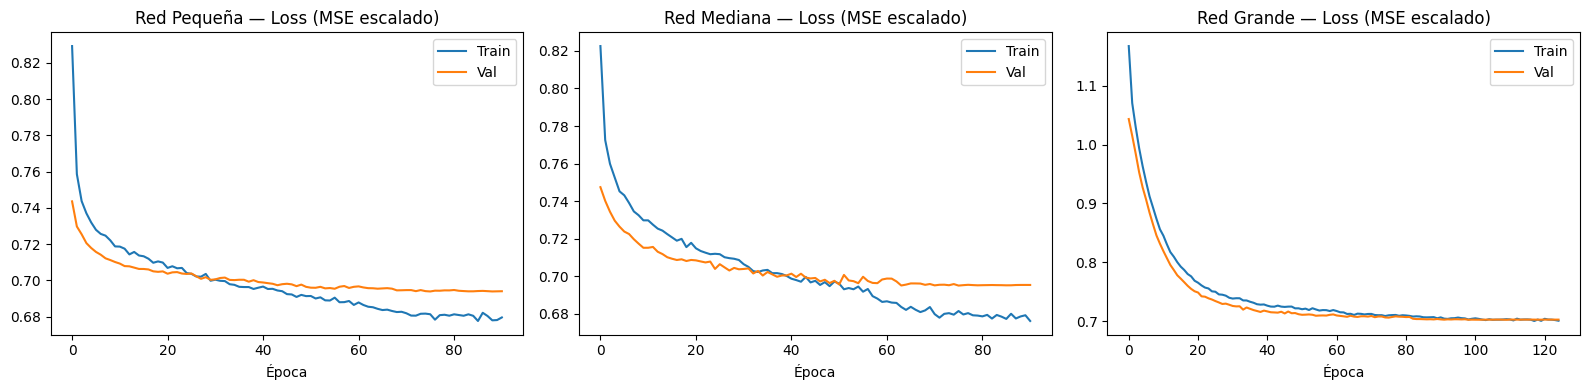

In [33]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Val')
    ax.set_title(f'{name} — Loss (MSE escalado)')
    ax.set_xlabel('Época'); ax.legend()
plt.tight_layout(); plt.show()

=== Comparativa final ===
     modelo  val_RMSE   val_MAE   val_R2  val_MAE_pct_rango  test_RMSE  test_MAE  test_R2  test_MAE_pct_rango  epochs_trained
 Red Grande 44.795245 36.396720 0.315111           7.279344  44.998443 36.524390 0.317418            7.304878           125.0
Red Mediana 44.931666 36.472508 0.310933           7.294502  45.090165 36.570827 0.314633            7.314165            91.0
RF_baseline 44.841956 36.429388 0.313681           7.285878  45.094254 36.515103 0.314508            7.303021             NaN
Red Pequeña 45.020168 36.577987 0.308215           7.315597  45.211730 36.730804 0.310932            7.346161            91.0

>>> Mejor modelo por R² en TEST: Red Grande


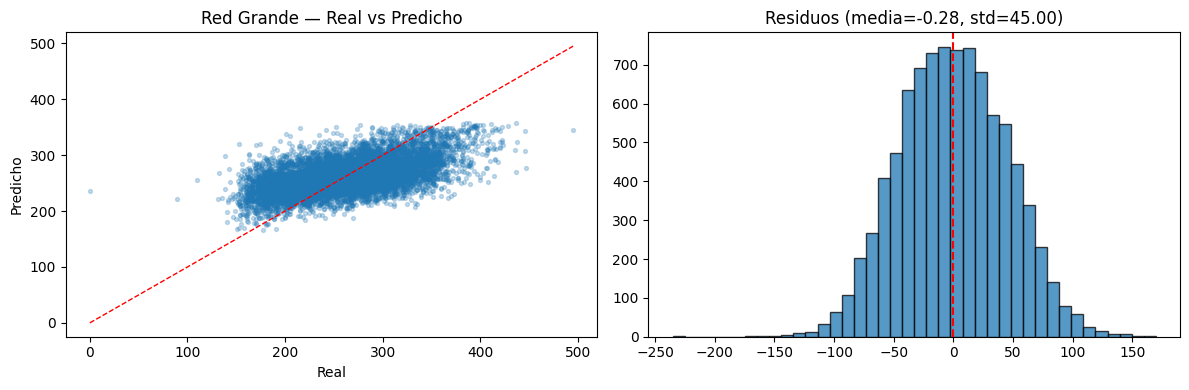


Error por estrato (TEST):
            n    MAE  sesgo
estrato                    
0         152  36.71   1.54
1        1617  34.69   0.25
2        3055  36.28  -1.55
3        2580  37.53  -0.29
4         848  37.59  -0.69
5         512  35.77   4.76
6         259  38.83   1.94


In [ ]:
# Tabla resumen
df_res = pd.DataFrame(resultados)
# Agregar RF al resumen
rf_row = {
    'modelo':'RF_baseline',
    **{f'val_{k}':v for k,v in m_val.items()},  # ← último m_val era NN_deep; recalculamos:
}
# Recalcular RF para asegurar valores correctos
rf_val  = evaluar(y_val,  rf.predict(X_val))
rf_test = evaluar(y_test, rf.predict(X_test))
rf_row = {'modelo':'RF_baseline',
          **{f'val_{k}':v for k,v in rf_val.items()},
          **{f'test_{k}':v for k,v in rf_test.items()},
          'epochs_trained': np.nan}
df_res = pd.concat([df_res, pd.DataFrame([rf_row])], ignore_index=True)
df_res = df_res.sort_values('test_R2', ascending=False).reset_index(drop=True)
print('=== Comparativa final ===')
print(df_res.to_string(index=False))

mejor = df_res.iloc[0]['modelo']
print(f'\n>>> Mejor modelo por R^2 en TEST: {mejor}')

if mejor.startswith('Red'):
    best_model = models[mejor]
    pred_test_s = best_model.predict(X_test_s, verbose=0).flatten()
    pred_test_best = Y_escalar.inverse_transform(pred_test_s.reshape(-1,1)).flatten()
else:
    best_model = rf
    pred_test_best = rf.predict(X_test)

plot_diagnostico(y_test, pred_test_best, mejor)

# Análisis del error por estrato (interés para la Sec. de Educación)
res_test = pd.DataFrame({'real': y_test, 'pred': pred_test_best,
                         'estrato': X_test['estrato_num'].values})
res_test['error'] = res_test['real'] - res_test['pred']
err_estrato = res_test.groupby('estrato').agg(
    n=('error','size'),
    MAE=('error', lambda s: np.mean(np.abs(s))),
    sesgo=('error','mean')
).round(2)
print('\nError por estrato (TEST):')
print(err_estrato)

In [35]:
if mejor.startswith("Red"):
    pred_val_best = Y_escalar.inverse_transform(
        models[mejor].predict(X_val_s, verbose=0).reshape(-1,1)).flatten()
else:
    pred_val_best = rf.predict(X_val)

residuos_val = y_val - pred_val_best
q_low, q_high = np.percentile(residuos_val, [0.5, 99.5])  # CI 99%
sigma_res = residuos_val.std()
print(f"Residuos validación: media={residuos_val.mean():.2f} | std={sigma_res:.2f}")
print(f"Cuantiles 99% CI: [{q_low:.2f}, {q_high:.2f}]")

# Verificar cobertura en TEST (debe estar cerca del 99%)
lim_inf_test = pred_test_best + q_low
lim_sup_test = pred_test_best + q_high
cobertura_test = np.mean((y_test >= lim_inf_test) & (y_test <= lim_sup_test)) * 100
print(f"Cobertura empírica en TEST: {cobertura_test:.2f}% (objetivo: 99%)")

Residuos validación: media=-0.37 | std=44.79
Cuantiles 99% CI: [-106.20, 110.46]
Cobertura empírica en TEST: 98.77% (objetivo: 99%)


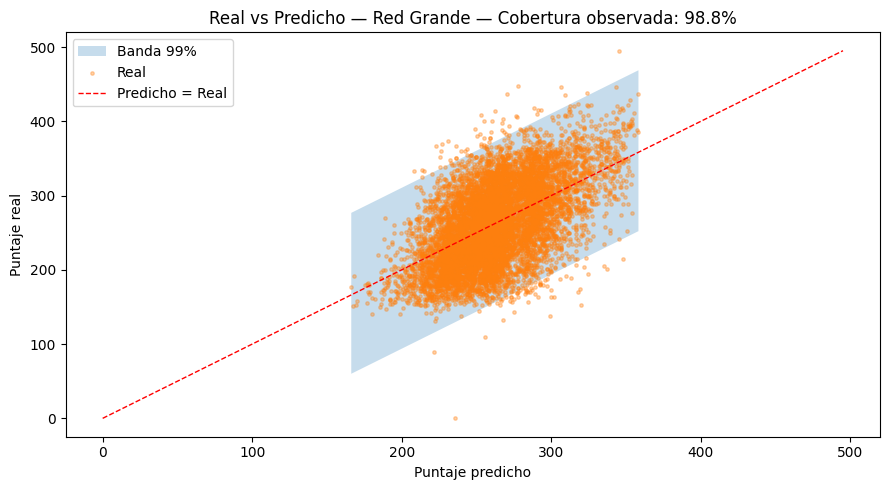

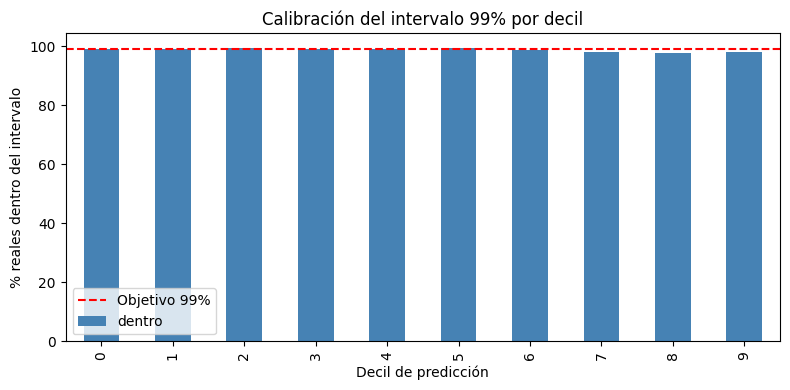

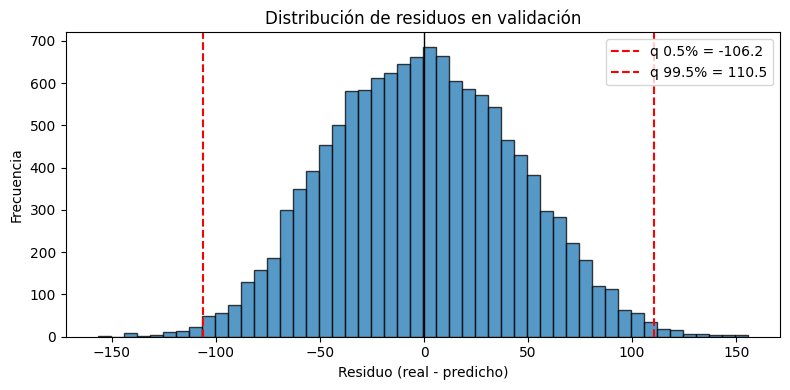

In [36]:
# 1) Real vs Predicho con banda al 99% en TEST
orden = np.argsort(pred_test_best)
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(pred_test_best[orden], lim_inf_test[orden], lim_sup_test[orden],
                alpha=0.25, label="Banda 99%")
ax.scatter(pred_test_best, y_test, s=6, alpha=0.35, label="Real")
lims = [min(y_test.min(), pred_test_best.min()), max(y_test.max(), pred_test_best.max())]
ax.plot(lims, lims, "r--", lw=1, label="Predicho = Real")
ax.set_xlabel("Puntaje predicho"); ax.set_ylabel("Puntaje real")
ax.set_title(f"Real vs Predicho — {mejor} — Cobertura observada: {cobertura_test:.1f}%")
ax.legend(); plt.tight_layout(); plt.show()

# 2) Calibración por decil de predicción
deciles = pd.qcut(pred_test_best, 10, labels=False, duplicates="drop")
calib = pd.DataFrame({"decil":deciles,
                     "dentro":(y_test>=lim_inf_test)&(y_test<=lim_sup_test)})
calib_pct = calib.groupby("decil")["dentro"].mean()*100
fig, ax = plt.subplots(figsize=(8, 4))
calib_pct.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(99, color="red", ls="--", label="Objetivo 99%")
ax.set_ylabel("% reales dentro del intervalo"); ax.set_xlabel("Decil de predicción")
ax.set_title("Calibración del intervalo 99% por decil")
ax.legend(); plt.tight_layout(); plt.show()

# 3) Distribución de residuos
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuos_val, bins=50, edgecolor="black", alpha=0.75)
ax.axvline(q_low, color="red", ls="--", label=f"q 0.5% = {q_low:.1f}")
ax.axvline(q_high, color="red", ls="--", label=f"q 99.5% = {q_high:.1f}")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Residuo (real - predicho)"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de residuos en validación"); ax.legend()
plt.tight_layout(); plt.show()

In [40]:
from sklearn.ensemble import HistGradientBoostingRegressor

config_gbm = [
    {"name":"GBM_conservador", "max_depth":5, "lr":0.05, "max_iter":600, "min_samples_leaf":80, "l2":1.0},
    {"name":"GBM_balanceado",  "max_depth":7, "lr":0.05, "max_iter":800, "min_samples_leaf":50, "l2":0.5},
    {"name":"GBM_flexible",    "max_depth":9, "lr":0.03, "max_iter":1200,"min_samples_leaf":30, "l2":0.1},
]
gbm_results = {}
for cfg in config_gbm:
    with mlflow.start_run(run_name=cfg["name"]):
        gbm = HistGradientBoostingRegressor(
            max_iter=cfg["max_iter"], max_depth=cfg["max_depth"],
            learning_rate=cfg["lr"], l2_regularization=cfg["l2"],
            min_samples_leaf=cfg["min_samples_leaf"],
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=25,
            random_state=semilla)
        gbm.fit(X_train, y_train)
        # Diagnóstico de sobreajuste: train vs val
        m_tr  = evaluar(y_train, gbm.predict(X_train), f'{cfg["name"]} TRAIN')
        m_val = evaluar(y_val,   gbm.predict(X_val),   f'{cfg["name"]} VAL  ')
        m_test= evaluar(y_test,  gbm.predict(X_test),  f'{cfg["name"]} TEST ')
        mlflow.log_params({**{k:v for k,v in cfg.items() if k!="name"}, "model_type":"HistGBM"})
        for k,v in m_val.items():  mlflow.log_metric(f"val_{k}", v)
        for k,v in m_test.items(): mlflow.log_metric(f"test_{k}", v)
        mlflow.log_metric("gap_R2_train_val", m_tr["R2"] - m_val["R2"])  # >0.05 = sobreajuste
        mlflow.sklearn.log_model(gbm, name=cfg["name"])
        gbm_results[cfg["name"]] = (gbm, m_val, m_test, m_tr)

  [GBM_conservador TRAIN]  RMSE=42.34 | MAE=34.23 | R²=0.391 | MAE%rango=6.85%
  [GBM_conservador VAL  ]  RMSE=43.57 | MAE=35.20 | R²=0.352 | MAE%rango=7.04%
  [GBM_conservador TEST ]  RMSE=43.71 | MAE=35.42 | R²=0.356 | MAE%rango=7.08%


2026/05/19 17:47:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [GBM_balanceado TRAIN]  RMSE=42.05 | MAE=33.98 | R²=0.400 | MAE%rango=6.80%
  [GBM_balanceado VAL  ]  RMSE=43.54 | MAE=35.17 | R²=0.353 | MAE%rango=7.03%
  [GBM_balanceado TEST ]  RMSE=43.69 | MAE=35.36 | R²=0.356 | MAE%rango=7.07%


2026/05/19 17:47:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [GBM_flexible TRAIN]  RMSE=42.03 | MAE=33.99 | R²=0.400 | MAE%rango=6.80%
  [GBM_flexible VAL  ]  RMSE=43.53 | MAE=35.19 | R²=0.353 | MAE%rango=7.04%
  [GBM_flexible TEST ]  RMSE=43.66 | MAE=35.36 | R²=0.357 | MAE%rango=7.07%


2026/05/19 17:47:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
